In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

np.random.seed(42)
X = np.sort(np.random.uniform(-3, 3, 100))
y = 0.5 * X**3 - X**2 + 2*X + np.random.normal(0, 3, 100)  # cubic + noise

X_train, X_test, y_train, y_test = train_test_split(
    X.reshape(-1,1), y, test_size=0.2, random_state=42
)

In [ ]:
degrees = [1, 3, 10]
results = {}

for d in degrees:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2  = r2_score(y_test,  pipe.predict(X_test))
    results[d] = {'pipe': pipe, 'train': train_r2, 'test': test_r2}
    print(f"Degree {d:2d} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

Degree  1 | Train R²: 0.8027 | Test R²: 0.7866
Degree  3 | Train R²: 0.9210 | Test R²: 0.9394
Degree 10 | Train R²: 0.9276 | Test R²: 0.9360


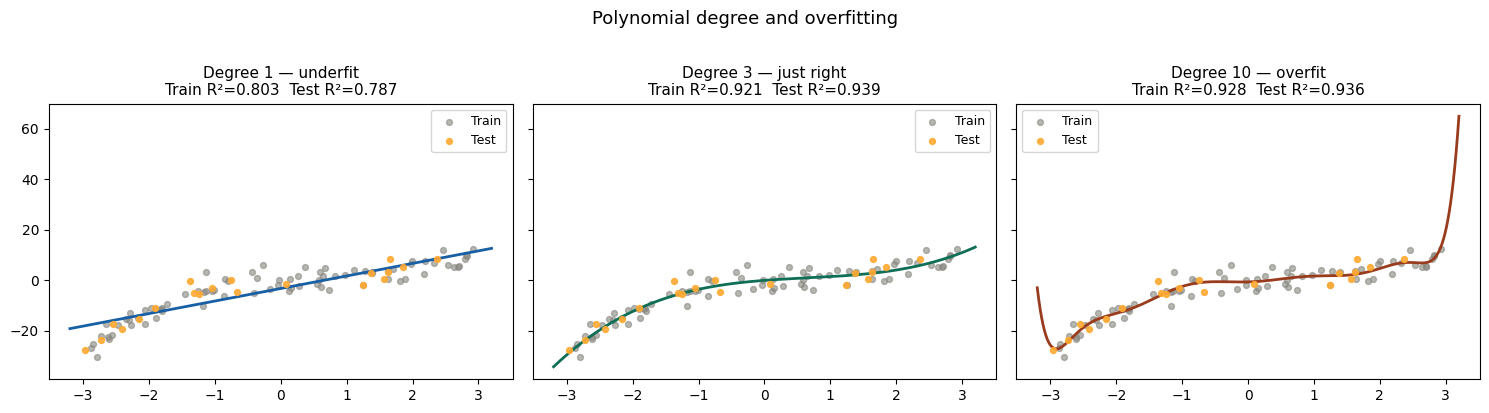

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
x_line = np.linspace(-3.2, 3.2, 300).reshape(-1,1)
colors = ['#185FA5', '#0F6E56', '#993C1D']
labels = ['Degree 1 — underfit', 'Degree 3 — just right', 'Degree 10 — overfit']

for ax, d, col, lbl in zip(axes, degrees, colors, labels):
    ax.scatter(X_train, y_train, s=18, alpha=0.6, color='#888780', label='Train')
    ax.scatter(X_test,  y_test,  s=18, alpha=0.9, color='#FFAA33', label='Test', zorder=3)
    ax.plot(x_line, results[d]['pipe'].predict(x_line), color=col, linewidth=2)
    ax.set_title(f'{lbl}\nTrain R²={results[d]["train"]:.3f}  Test R²={results[d]["test"]:.3f}',
                 fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Polynomial degree and overfitting', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Use cross_val_score to find the polynomial degree that maximises validation R².

Degree  1: CV R² = -1.7865 ± 1.2926
Degree  2: CV R² = -3.5622 ± 4.6016
Degree  3: CV R² = 0.3038 ± 0.3160
Degree  4: CV R² = -0.3653 ± 0.7802
Degree  5: CV R² = -0.0922 ± 0.4799
Degree  6: CV R² = -46.6337 ± 90.0760
Degree  7: CV R² = -27.2429 ± 48.9431
Degree  8: CV R² = -1522.0156 ± 2755.1732
Degree  9: CV R² = -5095.4277 ± 10176.9235
Degree 10: CV R² = -19252.5150 ± 33533.9343
Degree 11: CV R² = -690858.0468 ± 1366130.8267

Best degree by cross-validation: 3


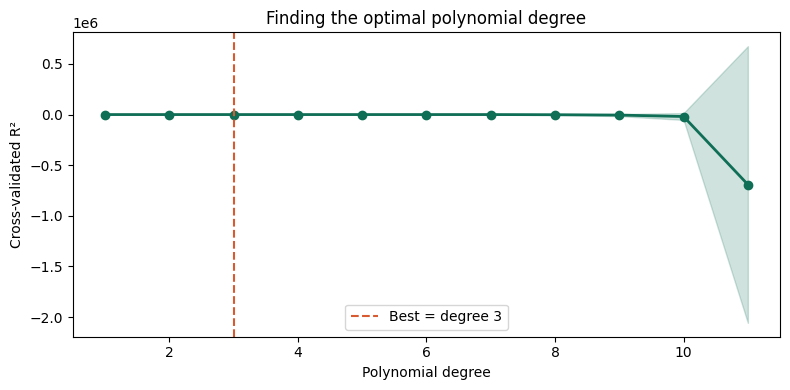

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

cv_means, cv_stds = [], []

for d in range(1, 12):
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipe, X.reshape(-1,1), y,
                             cv=5, scoring='r2')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"Degree {d:2d}: CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

best_degree = np.argmax(cv_means) + 1
print(f"\nBest degree by cross-validation: {best_degree}")

plt.figure(figsize=(8, 4))
plt.plot(range(1,12), cv_means, 'o-', color='#0F6E56', linewidth=2)
plt.fill_between(range(1,12),
                 np.array(cv_means)-np.array(cv_stds),
                 np.array(cv_means)+np.array(cv_stds),
                 alpha=0.2, color='#0F6E56')
plt.axvline(best_degree, color='#D85A30', linestyle='--', label=f'Best = degree {best_degree}')
plt.xlabel('Polynomial degree')
plt.ylabel('Cross-validated R²')
plt.title('Finding the optimal polynomial degree')
plt.legend()
plt.tight_layout()
plt.show()

What happens to coefficients as degree increases? Print them for degree 1, 3, 5, 10.

In [ ]:
for d in [1, 3, 5, 10]:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    coefs = pipe.named_steps['model'].coef_
    intercept = pipe.named_steps['model'].intercept_
    max_coef = np.max(np.abs(coefs))

    print(f"\nDegree {d}: {len(coefs)} coefficients")
    print(f"  Intercept: {intercept:.2f}")
    print(f"  Max |coef|: {max_coef:.2f}")
    print(f"  Coefs: {np.round(coefs[:5], 2)} {'...' if len(coefs)>5 else ''}")


Degree 1: 1 coefficients
  Intercept: -3.25
  Max |coef|: 4.96
  Coefs: [4.96] 

Degree 3: 3 coefficients
  Intercept: -0.04
  Max |coef|: 1.98
  Coefs: [ 1.98 -1.03  0.53] 

Degree 5: 5 coefficients
  Intercept: -0.02
  Max |coef|: 1.63
  Coefs: [ 1.63 -1.03  0.71  0.   -0.02] 

Degree 10: 10 coefficients
  Intercept: -0.64
  Max |coef|: 4.66
  Coefs: [ 0.69  3.52  1.51 -4.66 -0.12] ...


Try PolynomialFeatures(degree=2) on all 8 California Housing features. Does R² improve?

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = fetch_california_housing()
X_cal, y_cal = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X_cal, y_cal,
                                           test_size=0.2, random_state=42)

# Baseline: plain linear
base = Pipeline([('scaler', StandardScaler()),
                 ('model',  LinearRegression())])
base.fit(X_tr, y_tr)
r2_base = r2_score(y_te, base.predict(X_te))

d = 2
poly2 = Pipeline([('scaler', StandardScaler()),
                  ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
                  ('model',  LinearRegression())])
poly2.fit(X_tr, y_tr)
r2_poly = r2_score(y_te, poly2.predict(X_te))

n_features_poly = poly2.named_steps['poly'].n_output_features_
print(f"Original features:         8")
print(f"After degree-2 expansion:  {n_features_poly}")
print(f"\nBaseline  R²: {r2_base:.4f}")
print(f"Degree-{d}  R²: {r2_poly:.4f}")
print(f"Improvement:  {r2_poly - r2_base:.4f}")

Original features:         8
After degree-2 expansion:  44

Baseline  R²: 0.5758
Degree-2  R²: 0.6457
Improvement:  0.0699



Why is it critical to put PolynomialFeatures inside a Pipeline rather than transforming X before splitting?

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# ✗ WRONG — transform BEFORE split (data leakage)
poly_wrong = PolynomialFeatures(degree=5, include_bias=False)
X_transformed_all = poly_wrong.fit_transform(X.reshape(-1,1))  # sees ALL data
scores_leaky = cross_val_score(LinearRegression(),
                               X_transformed_all, y, cv=5, scoring='r2')

# ✓ CORRECT — transform INSIDE Pipeline (no leakage)
pipe_correct = Pipeline([
    ('poly',  PolynomialFeatures(degree=5, include_bias=False)),
    ('model', LinearRegression())
])
scores_correct = cross_val_score(pipe_correct,
                                 X.reshape(-1,1), y, cv=5, scoring='r2')

print(f"Leaky  CV R²:   {scores_leaky.mean():.4f}  ← artificially inflated")
print(f"Correct CV R²:  {scores_correct.mean():.4f}  ← honest estimate")
print(f"\nOver-estimate caused by leakage: +{scores_leaky.mean()-scores_correct.mean():.4f}")

Leaky  CV R²:   -0.0922  ← artificially inflated
Correct CV R²:  -0.0922  ← honest estimate

Over-estimate caused by leakage: +0.0000
